In [1]:
import pandas as pd
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt 
import yaml
import os
import sys

plt.style.use("~/evanstyle.mplstyle") #replace with your own or comment

sys.path.append("../")
import CryoAsicAnalysis


In [2]:
#redfile_sig = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/6g24pt_sig/combined.p"
#redfile_bk = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"
#or on llnl
redfile_sig = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_sig/combined.p"
redfile_bk = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"

df_sig = pickle.load(open(redfile_sig, "rb"))[0]
df_bk = pickle.load(open(redfile_bk, "rb"))[0]


loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file1197.p
Done loading


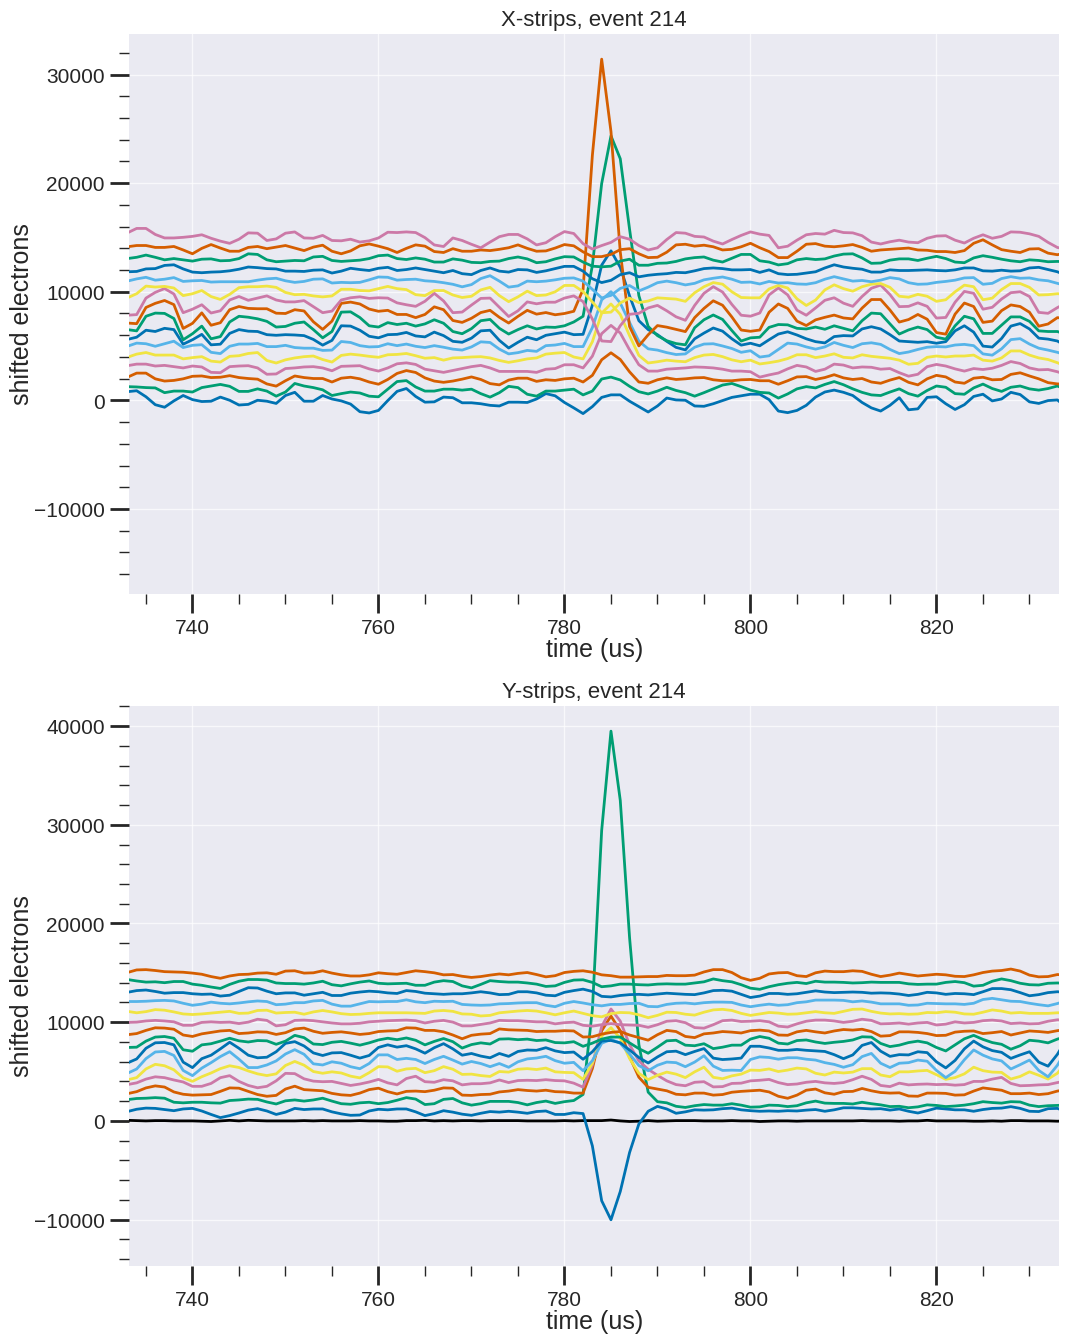

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file514.p
Done loading


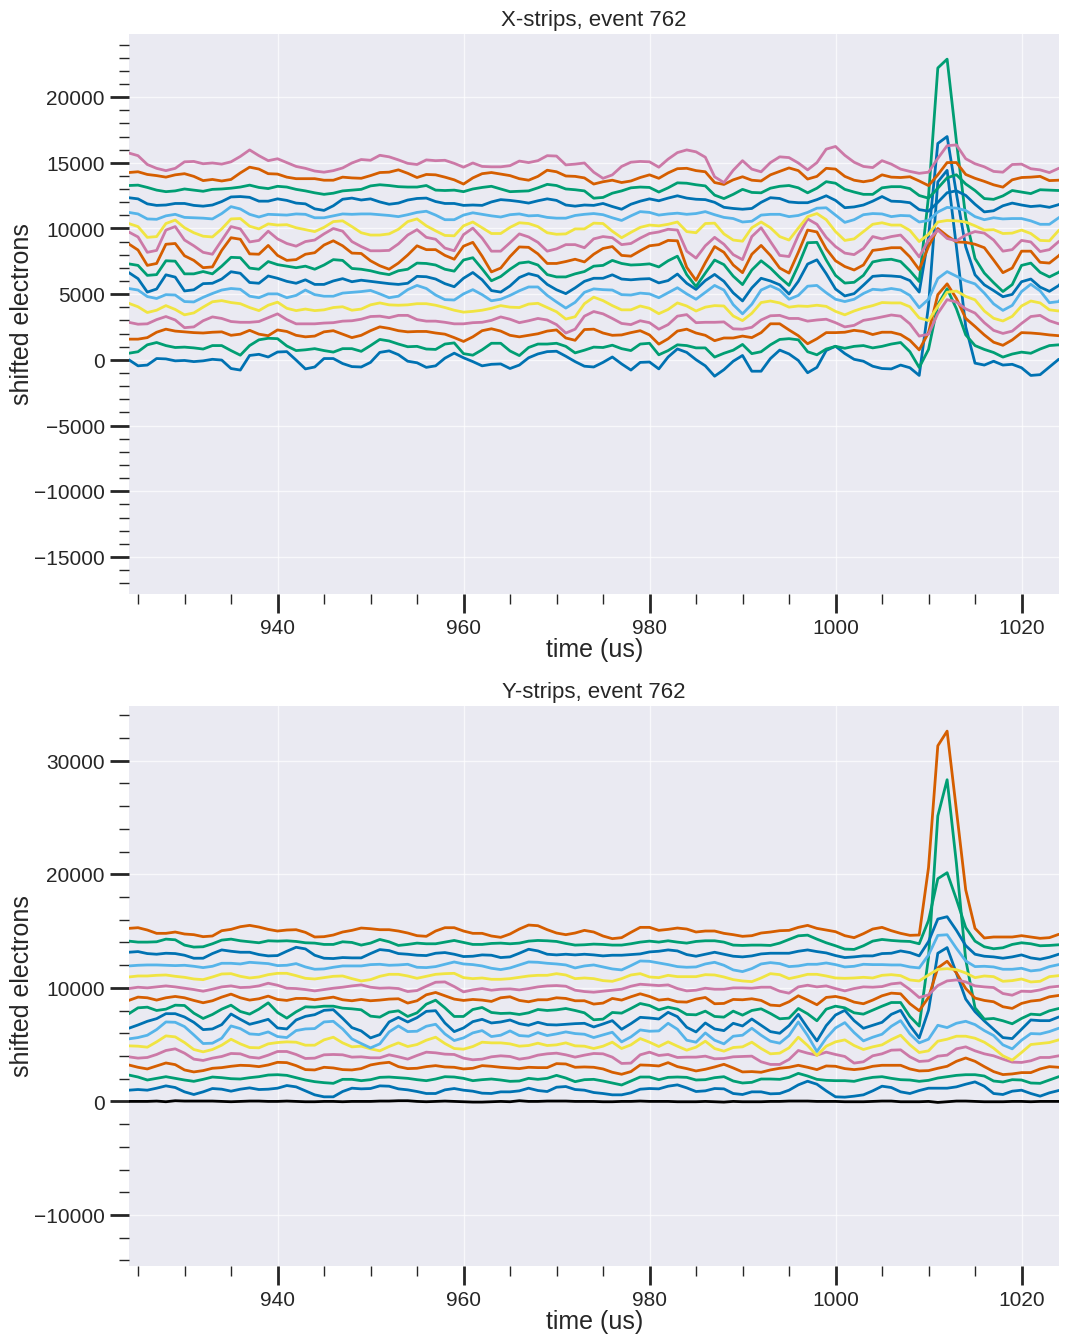

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file494.p
Done loading


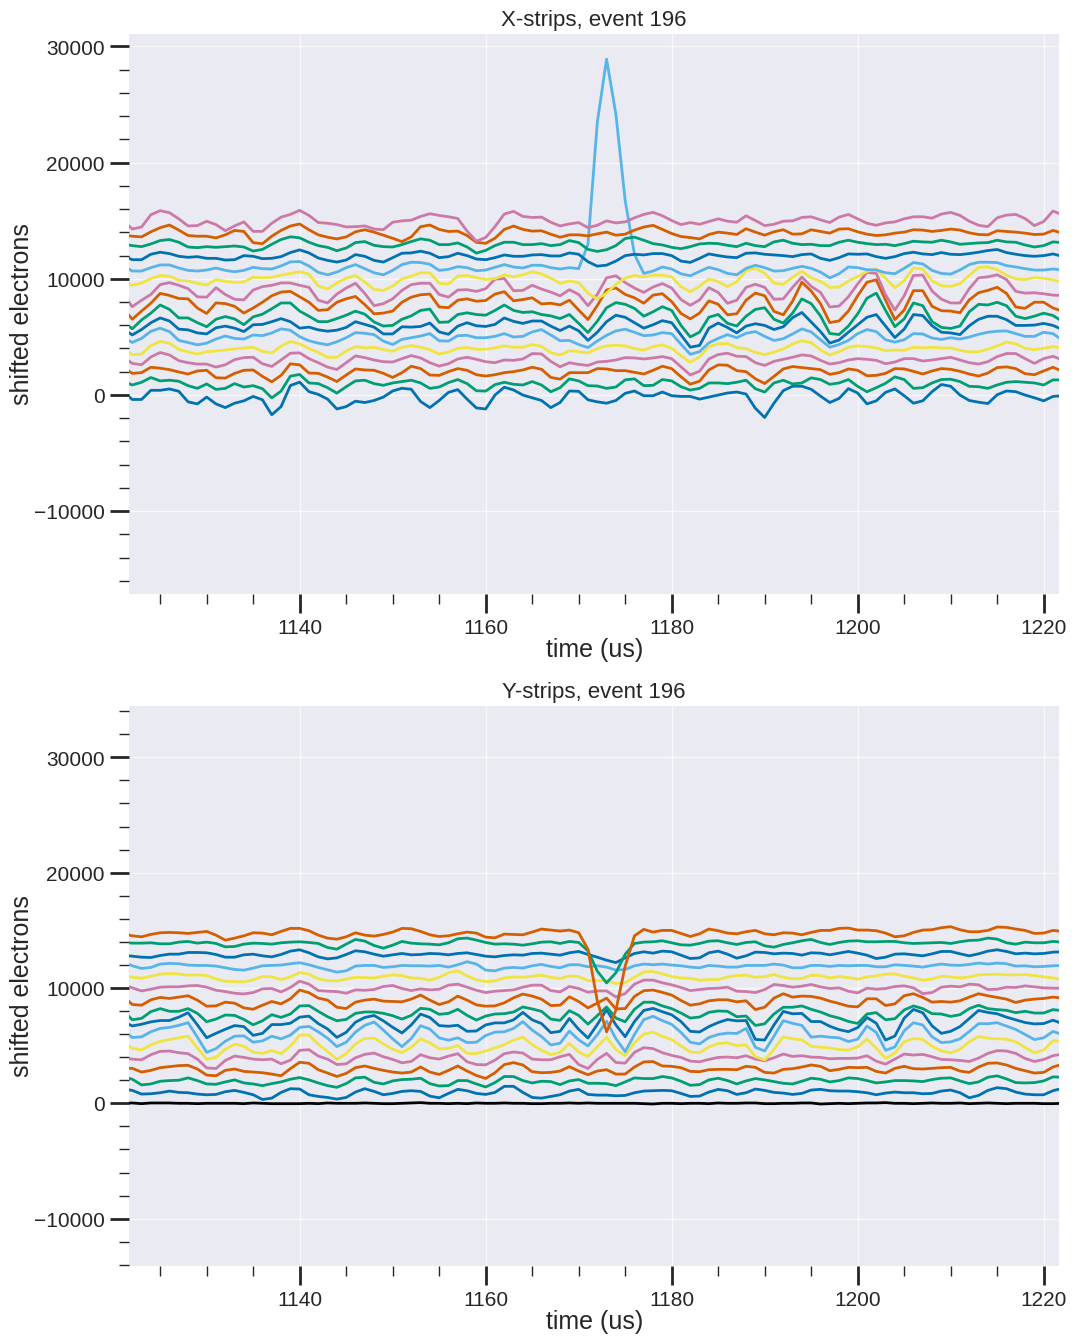

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file1031.p
Done loading


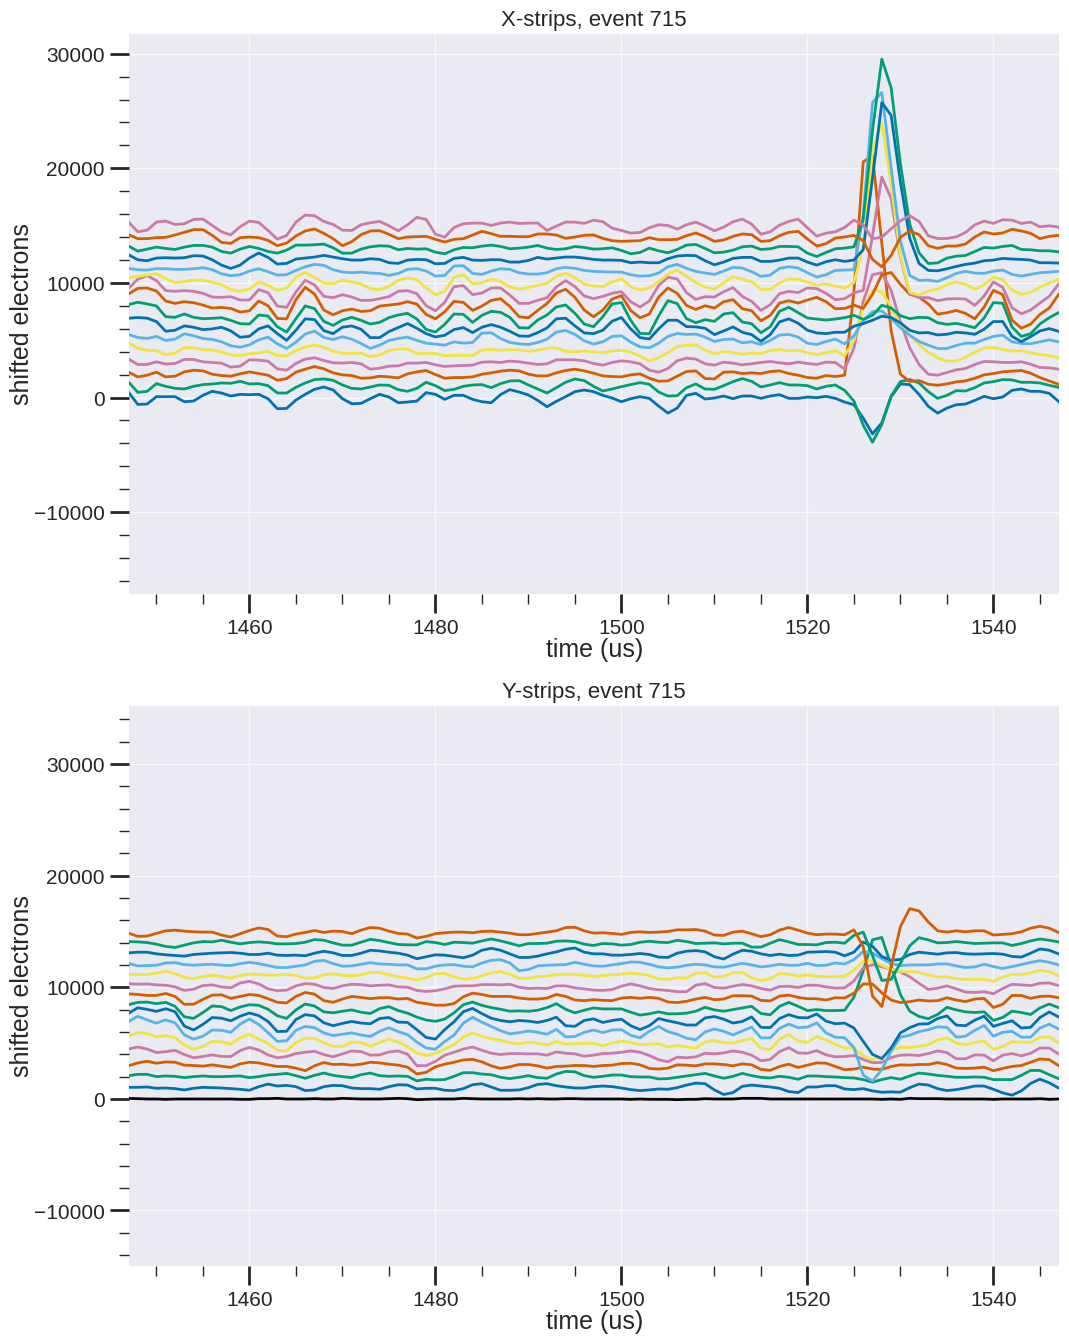

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file494.p
Done loading


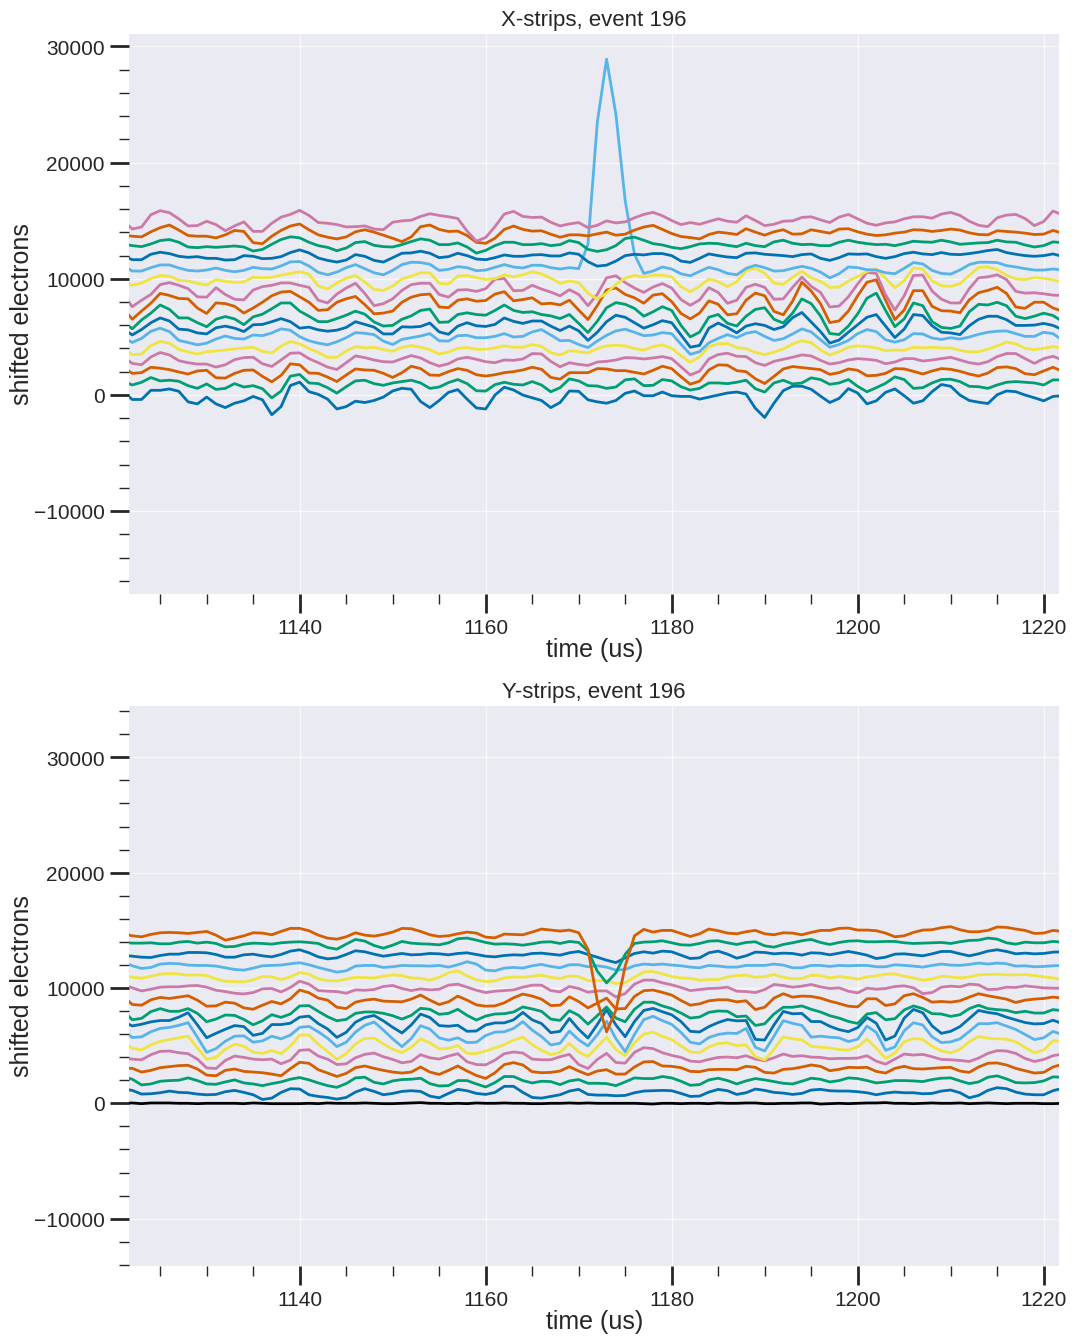

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file982.p
Done loading


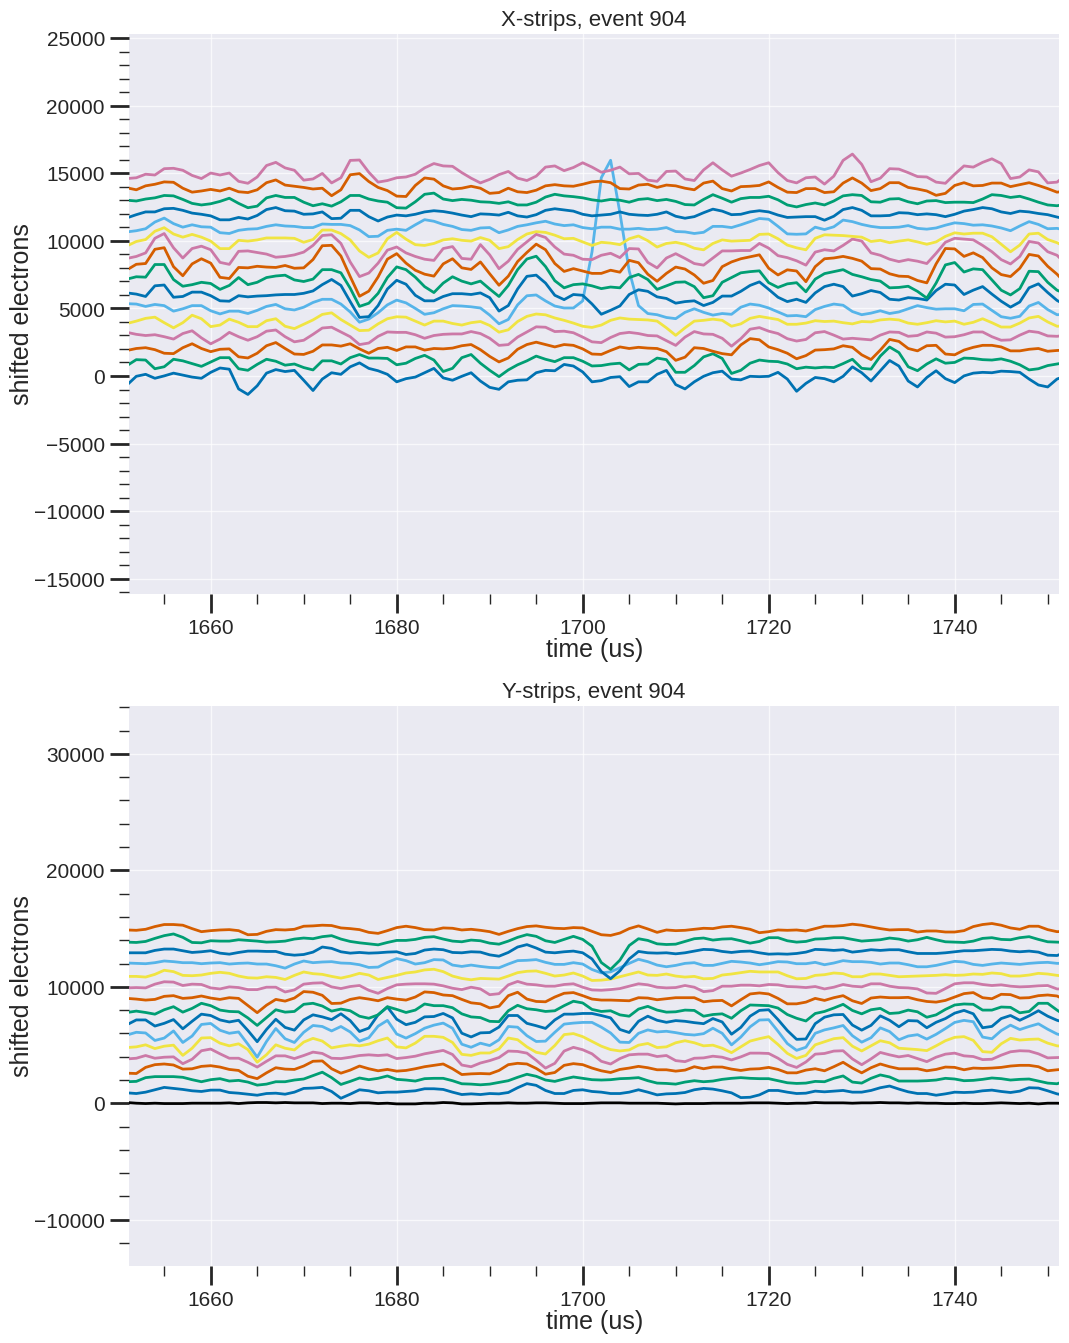

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file514.p
Done loading


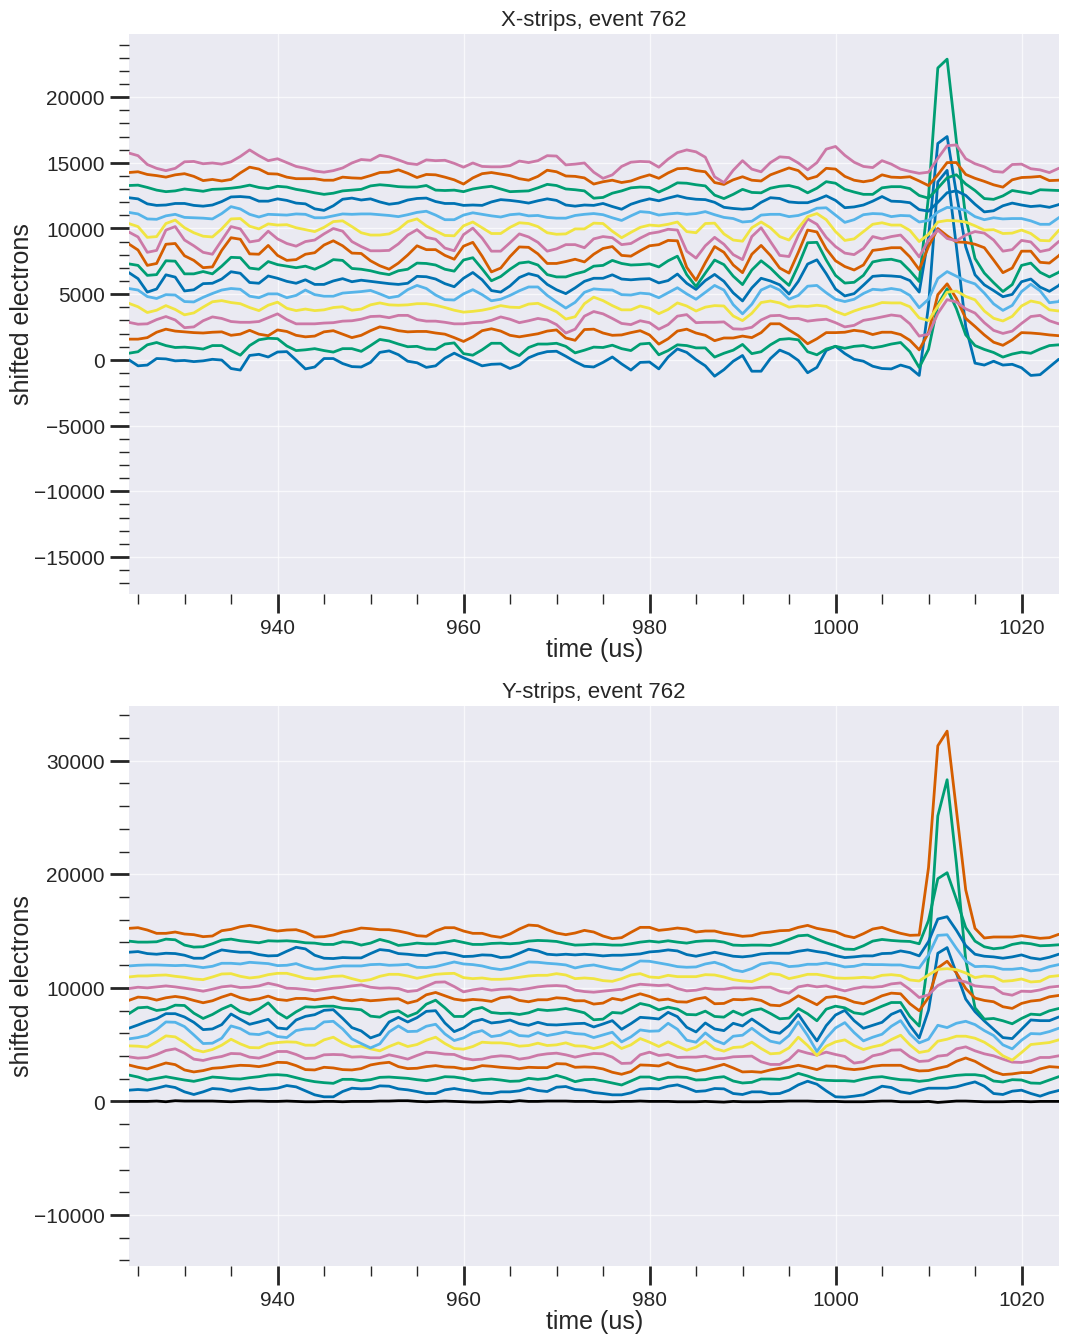

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file982.p
Done loading


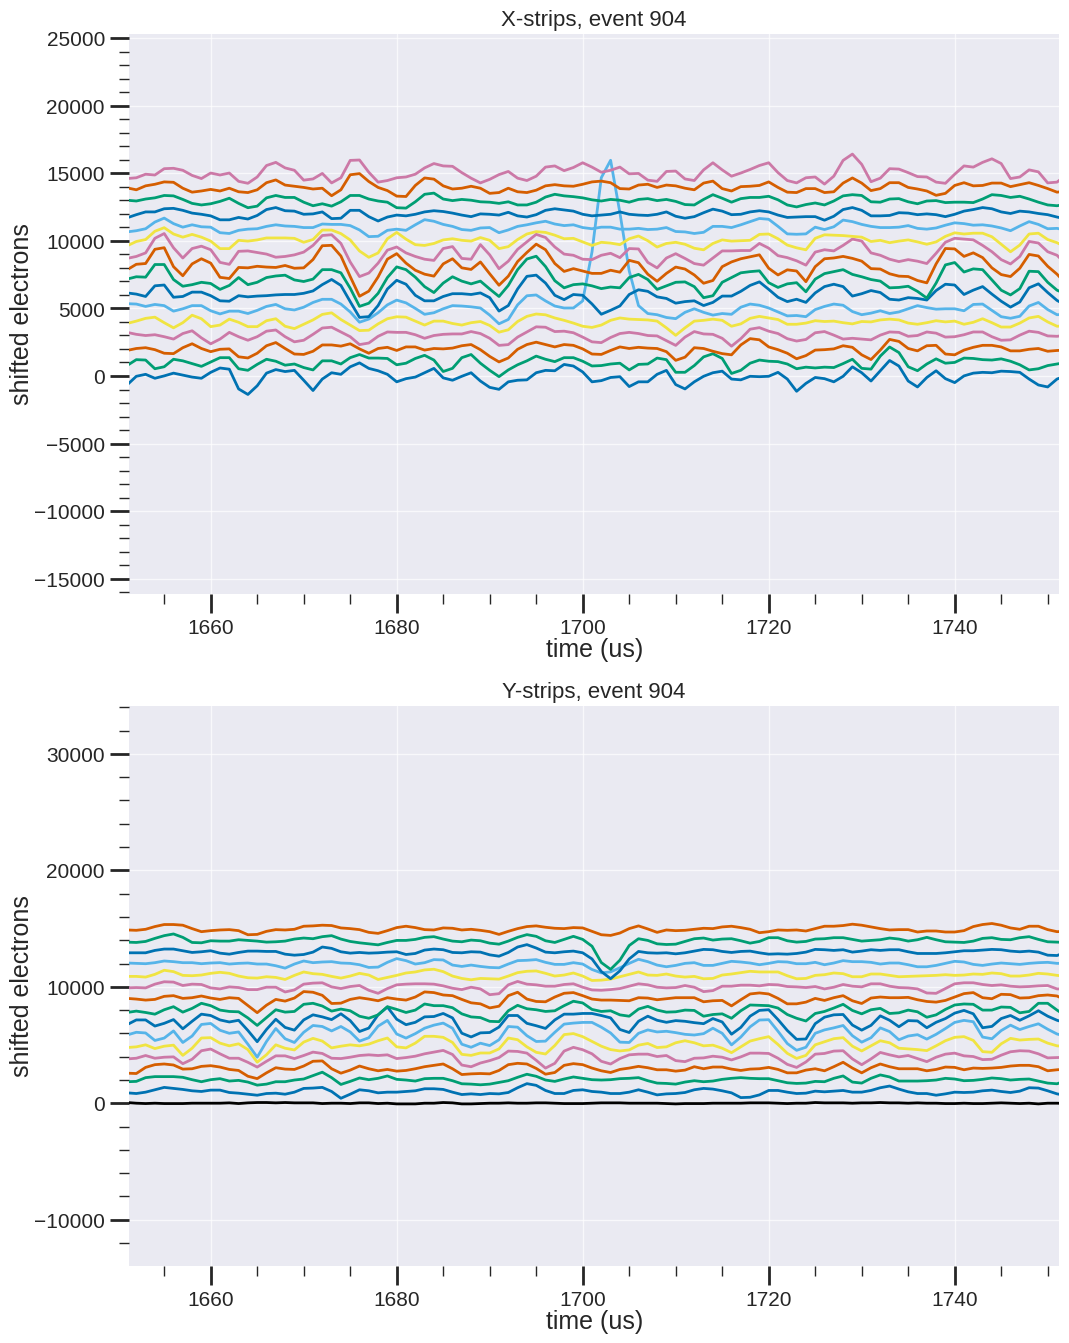

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file379.p
Done loading


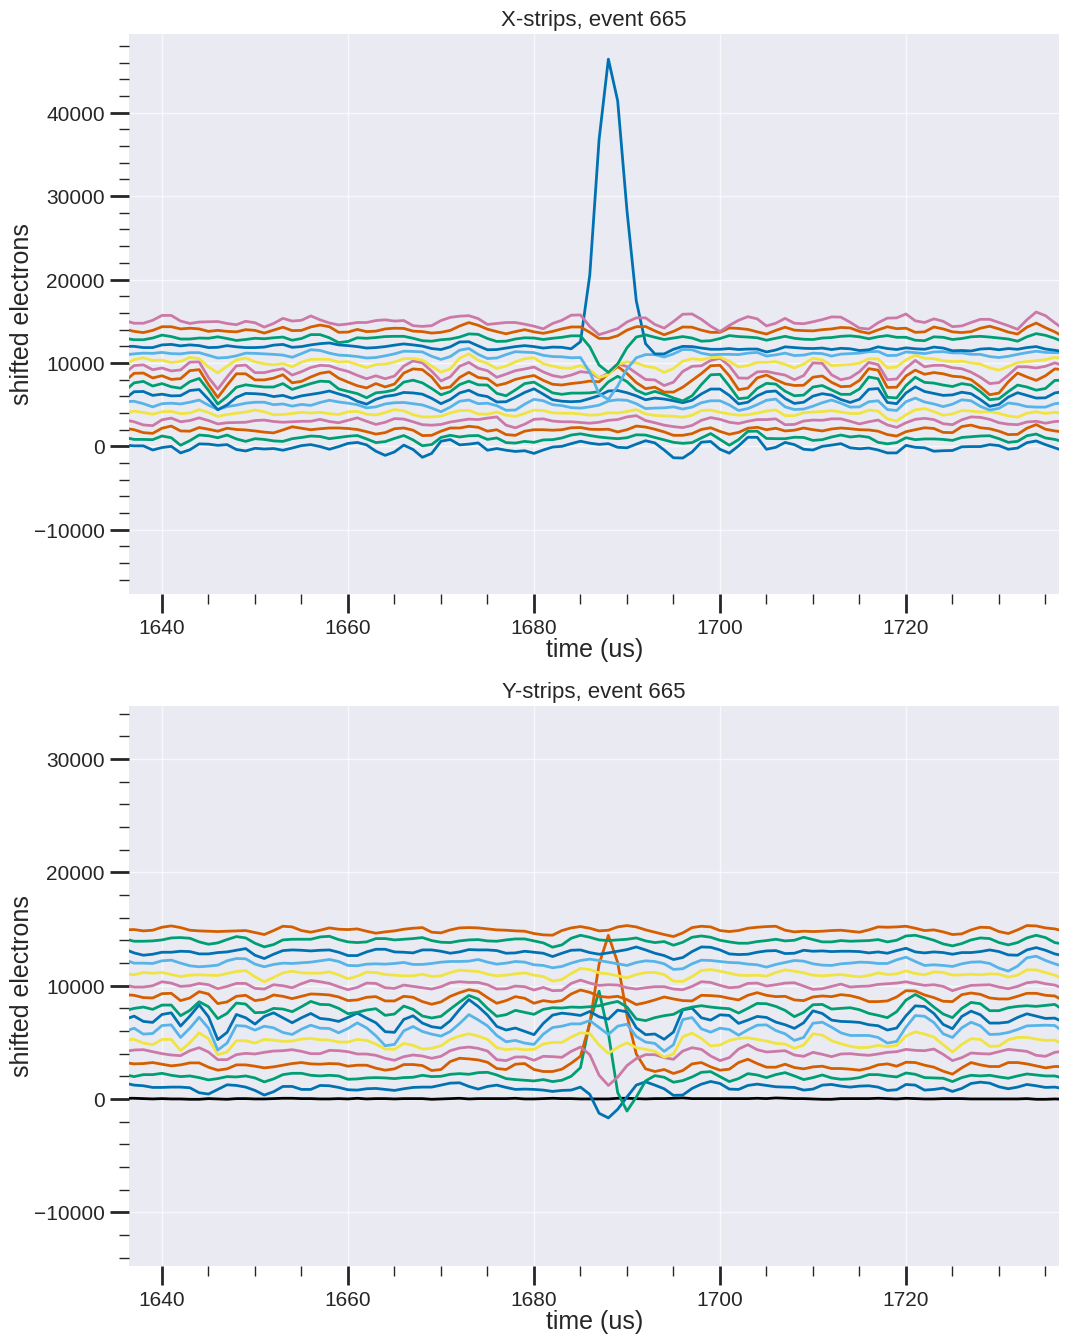

loading the waveform dataframe from  /p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/prereduced/6g24pt_sig/Gamma_Data_5kV_7_16_24_initcryo_4_6g_24pt_1000us_file1197.p
Done loading


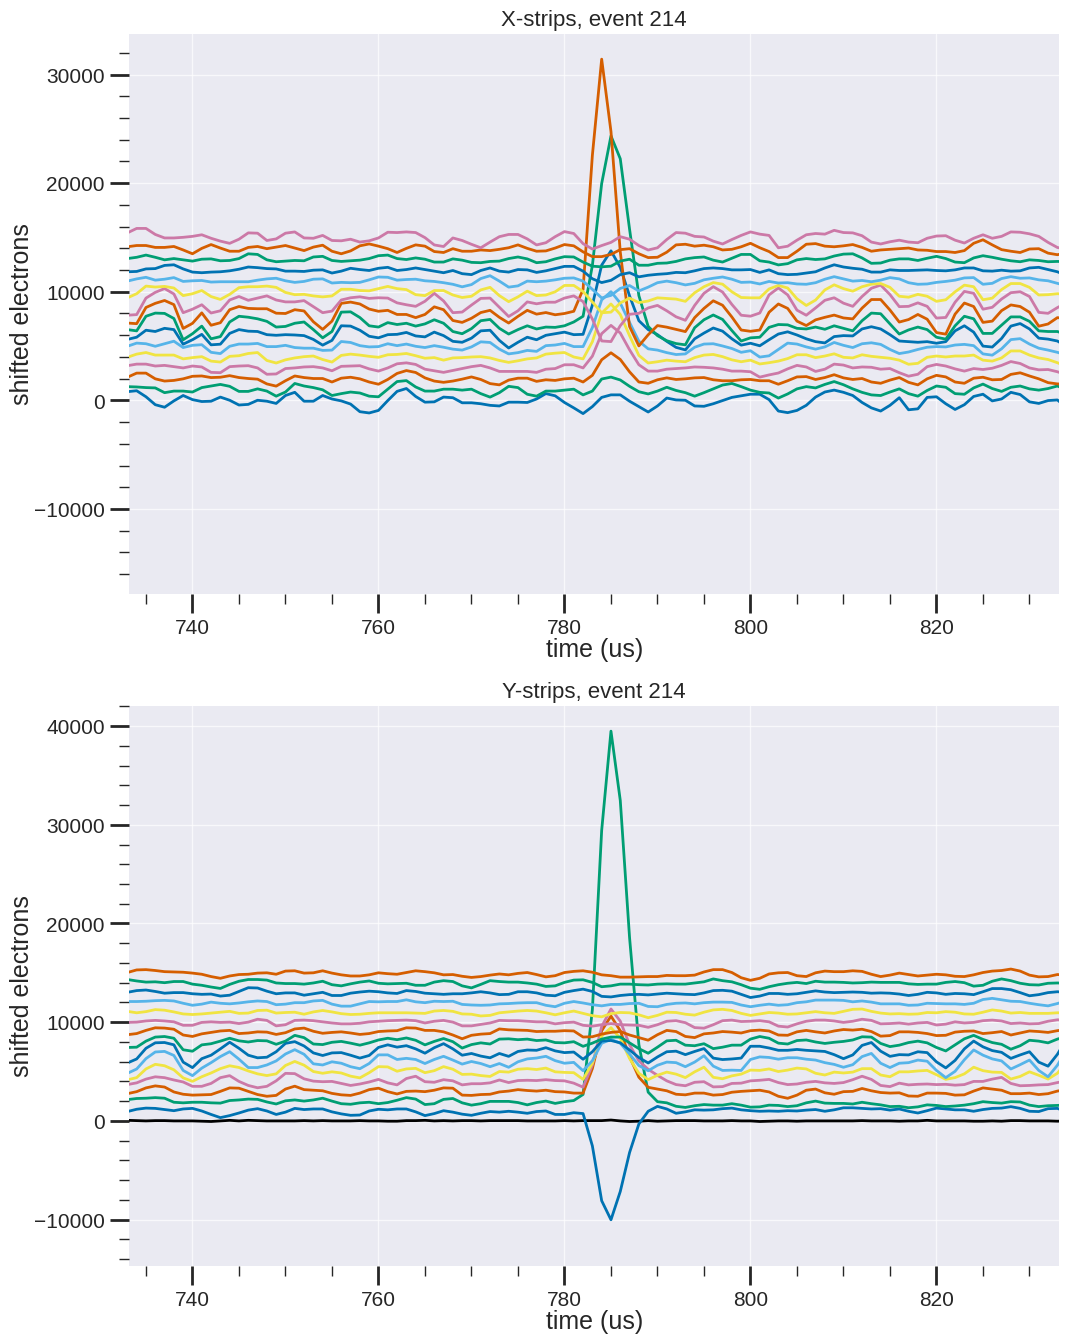

In [7]:

#change to your path
config_path = "/g/g15/angelico/cryo-asic-analysis/config/gamma-post-surg-24.yml"


#a cut that I want to look at
mask = (df_sig["n_pulses"] > 4) & (df_sig["n_pulses"] < 7) & (df_sig["total_charge"] > 10000)

#plot N random events from the events that pass this cut
n = 10
df_idxs = np.random.choice(df_sig[mask].index, n)
for idx in df_idxs:
    ev = df_sig[mask].loc[idx]
    filename = ev["filename"]
    evidx = ev["evidx"]
    arrival = ev["t"]
    #check if this file is accessible 
    if not os.path.exists(filename):
        print("File not found: ", filename)
        continue
    #load the file
    ca = CryoAsicAnalysis.CryoAsicAnalysis(filename, config_path)
    ca.baseline_subtract()
    fig, ax = ca.plot_strips_waveforms_separated(evidx, sep=1000, show=False)
    ax[0].set_xlim([arrival-50, arrival+50])
    ax[1].set_xlim([arrival-50, arrival+50])
    plt.show()


